In [1]:
!pip install -q roboflow ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 250.0/250.0 kB 15.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 18.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 59.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 67.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 104.9 MB/s eta 0:00:00


In [2]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="E9Pyxhe86Ve7S2UDXHPT")
project = rf.workspace("roboflow-100").project("vehicles-q0x2v")
version = project.version(1)
dataset = version.download("yolov8")


loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to vehicles-1 in yolov8:: 100%|██████████| 8128/8128 [00:01<00:00, 7103.63it/s]


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [3]:
from ultralytics import YOLO

# Load a pre-trained model (e.g., YOLO11 nano for fast training)
model = YOLO("yolo11n.pt")

# Train the model on your downloaded dataset
# You can increase 'epochs' depending on the size and complexity of your vehicle dataset
results = model.train(
    data=f"{dataset.location}/data.yaml",
    epochs=5,
    imgsz=640,
    plots=True
)

Ultralytics 8.4.75 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/vehicles-1/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=5, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, 


image 1/458 /content/vehicles-1/test/images/adit_mp4-1002_jpg.rf.9effa5a5f1b95f251194f16d122d5ef0.jpg: 640x640 8 cars, 1 truck-l-, 1 truck-m-, 1 truck-xl-, 10.2ms
image 2/458 /content/vehicles-1/test/images/adit_mp4-1008_jpg.rf.78a4956560a79d1d8f3611b00baa8785.jpg: 640x640 10 cars, 2 truck-l-s, 1 truck-m-, 1 truck-xl-, 30.7ms
image 3/458 /content/vehicles-1/test/images/adit_mp4-1022_jpg.rf.d0e360f994683fc8b1bc9ebfa684a1ec.jpg: 640x640 7 cars, 1 truck-m-, 15.7ms
image 4/458 /content/vehicles-1/test/images/adit_mp4-1028_jpg.rf.4406265d3ebaeb90517f5ea54c0f6e2d.jpg: 640x640 9 cars, 1 truck-m-, 38.4ms
image 5/458 /content/vehicles-1/test/images/adit_mp4-1035_jpg.rf.ecbd9a641b73bd1c44a6dd74c11231bd.jpg: 640x640 6 cars, 1 truck-m-, 51.9ms
image 6/458 /content/vehicles-1/test/images/adit_mp4-1049_jpg.rf.fde8c661e90c6d526aba435b4b30893a.jpg: 640x640 6 cars, 1 truck-l-, 1 truck-m-, 1 truck-xl-, 13.8ms
image 7/458 /content/vehicles-1/test/images/adit_mp4-1055_jpg.rf.59812e37fed36591269646fc43d47

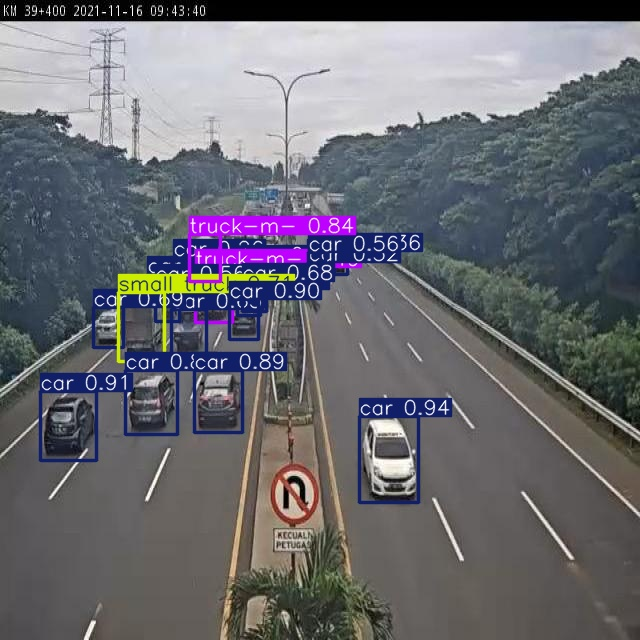

In [4]:
import glob
from IPython.display import Image, display

# Run inference on the test images
model.predict(source=f"{dataset.location}/test/images", save=True)

# Display one of the predicted images to see the generated bounding boxes
predicted_images = glob.glob('runs/detect/predict/*.jpg')
if predicted_images:
    display(Image(filename=predicted_images[0]))